In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
from src.loading_data.load_data import get_data, get_2022_data
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from src.stream_3.gower_distance import get_gower
from src.stream_3.gen_hdb_clus import GenerateHDBSCAN
import umap
import umap.plot

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\fergu\Do

In [2]:
df = get_2022_data()
df.head()

DataFrame Cleaned Successfully...
DataFrame Information:
>>> Columns:
Index(['Age9', 'Educ6', 'Eth7', 'Gend3', 'HHLiv12', 'IMD10', 'NSSEC5',
       'WorkStat10', 'MEMS7_ALL', 'Motiva_POP', 'motivd_POP', 'inclus_a',
       'comm1', 'happy', 'lifesat', 'lone', 'worthw', 'LOG_MEMS7_ALL',
       'active'],
      dtype='str')
>>> Shape (4668, 19)


,Age9,Educ6,Eth7,Gend3,HHLiv12,IMD10,NSSEC5,WorkStat10,MEMS7_ALL,Motiva_POP,motivd_POP,inclus_a,comm1,happy,lifesat,lone,worthw,LOG_MEMS7_ALL,active
54,6.0,1.0,1.0,1.0,1.0,4.0,3.0,4.0,0.0,1.0,5.0,1.0,3.0,7.0,7.0,4.0,7.0,0.000000,False
55,7.0,5.0,1.0,2.0,1.0,8.0,4.0,5.0,0.0,3.0,3.0,2.0,3.0,0.0,0.0,1.0,0.0,0.000000,False
58,4.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,6870.0,2.0,5.0,2.0,3.0,8.0,8.0,3.0,10.0,8.835065,True
81,4.0,1.0,7.0,2.0,6.0,2.0,1.0,1.0,690.0,2.0,4.0,3.0,4.0,6.0,7.0,4.0,8.0,6.538140,True
82,4.0,1.0,4.0,2.0,3.0,5.0,4.0,8.0,240.0,1.0,5.0,4.0,3.0,9.0,2.0,2.0,10.0,5.484797,True


In [3]:
catogs = ['Eth7', 'Gend3', 'HHLiv12', 'WorkStat10']
contins = ['Age9', 'Educ6', 'IMD10', 'NSSEC5', 'Motiva_POP', 'motivd_POP', 'happy', 'lifesat', 'lone', 'worthw', 'comm1', 'inclus_a']
targets = ['MEMS7_ALL', 'LOG_MEMS7_ALL', 'active']
mems = df['MEMS7_ALL'].values
log_mems = df['LOG_MEMS7_ALL'].values

In [4]:
distances = get_gower(df[catogs + contins], catogs)

Categorical Variables:
0 | True | Eth7
1 | True | Gend3
2 | True | HHLiv12
3 | True | WorkStat10
4 | False | Age9
5 | False | Educ6
6 | False | IMD10
7 | False | NSSEC5
8 | False | Motiva_POP
9 | False | motivd_POP
10 | False | happy
11 | False | lifesat
12 | False | lone
13 | False | worthw
14 | False | comm1
15 | False | inclus_a


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\plot.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[:, 0], points[:, 1], s=point_size, c=color)


<Axes: >

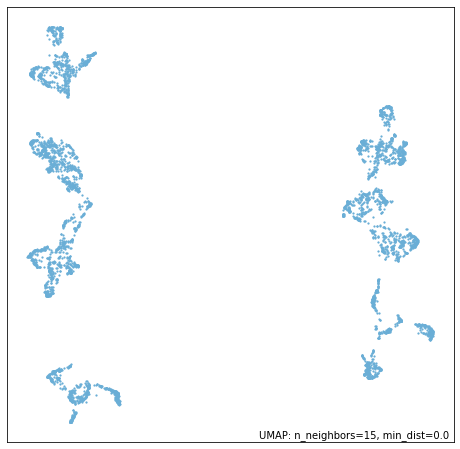

In [5]:
emb = umap.UMAP(random_state = 42, min_dist=0.0).fit(distances)
umap.plot.points(emb)

In [6]:
clusterer = GenerateHDBSCAN(emb.embedding_)

In [7]:
clusterer.hdb()

100%|██████████| 11/11 [00:20<00:00,  1.90s/it]

     min_sample  min_cluster cluster_selection     metric  num_clusters  \
76           10          500               eom  euclidean             4   
116          20          500               eom  euclidean             4   
104          20          350               eom  euclidean             4   
77           10          500               eom  manhattan             4   
73           10          450               eom  manhattan             4   

     unclustered_prop      dbcv  
76                0.0  0.851337  
116               0.0  0.843972  
104               0.0  0.843972  
77                0.0  0.843920  
73                0.0  0.843920  


,min_cluster_size,500
,min_samples,10
,cluster_selection_epsilon,0.0
,cluster_selection_persistence,0.0
,max_cluster_size,0
,metric,'euclidean'
,alpha,1.0
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)


In [8]:
c = clusterer.get_clusterer()
np.unique(c.labels_)

array([0, 1, 2, 3])

<Axes: >

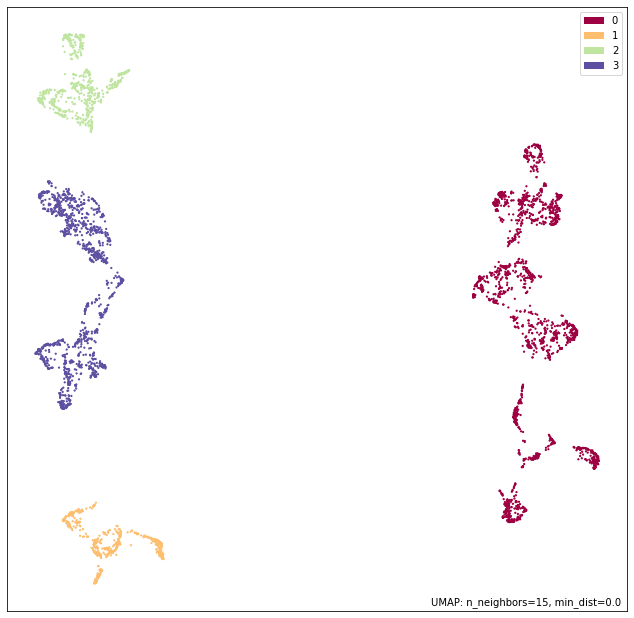

In [9]:
umap.plot.points(emb, labels=c.labels_)